In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from datasets import load_dataset
from tensorflow.keras.layers import TextVectorization

/Users/zoslaptop/ai-text-classifier/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("fancyzhx/ag_news")

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print(train_df.shape)
print(test_df.shape)

(120000, 2)
(7600, 2)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_df["text"],
    train_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

In [4]:
max_tokens = 20000
sequence_length = 100

vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length
)

In [5]:
vectorizer.adapt(X_train.to_numpy())

In [6]:
sample_text = [
    "Apple announced a new artificial intelligence platform."
]

encoded_text = vectorizer(sample_text)

print(encoded_text.numpy())

[[ 295  123    4   17 7150 1446 1725    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]]


In [7]:
from tensorflow.keras.layers import TextVectorization

vectorizer = TextVectorization(
    max_tokens=20000,
    output_mode="int",
    output_sequence_length=100
)

vectorizer.adapt(X_train.to_numpy())

In [8]:
sample_text = [
    "Apple announced a new artificial intelligence platform."
]

encoded_text = vectorizer(sample_text)

print(encoded_text.numpy()[:, :15])

[[ 295  123    4   17 7150 1446 1725    0    0    0    0    0    0    0
     0]]


In [9]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

In [10]:
embedding_model = Sequential([
    Input(shape=(100,)),
    Embedding(
        input_dim=20000,
        output_dim=64,
        mask_zero=True
    ),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(4, activation="softmax")
])

Input(shape=(100,))	Accepts 100 token IDs per article
Embedding(20000, 64)	Learns a 64-dimensional vector for each vocabulary entry
mask_zero=True	Marks padding tokens so compatible layers can ignore them
GlobalAveragePooling1D()	Averages the token vectors into one 64-value article representation
Dense(64, relu)	Learns patterns useful for classification
Dropout(0.3)	Helps reduce overfitting
Dense(4, softmax)	Produces probabilities for the four news categories

In [11]:
embedding_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
embedding_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,284,420 (4.90 MB)

 Trainable params: 1,284,420 (4.90 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
X_train_encoded = vectorizer(X_train.to_numpy()).numpy()
X_val_encoded = vectorizer(X_val.to_numpy()).numpy()

print(X_train_encoded.shape)
print(X_val_encoded.shape)

(96000, 100)
(24000, 100)


In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [15]:
history_embedding = embedding_model.fit(
    X_train_encoded,
    y_train,
    validation_data=(X_val_encoded, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stopping]
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8686 - loss: 0.4480 - val_accuracy: 0.9184 - val_loss: 0.2492
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9305 - loss: 0.2163 - val_accuracy: 0.9215 - val_loss: 0.2357
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9442 - loss: 0.1698 - val_accuracy: 0.9190 - val_loss: 0.2452
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9536 - loss: 0.1394 - val_accuracy: 0.9147 - val_loss: 0.2667


In [16]:
val_loss, val_accuracy = embedding_model.evaluate(
    X_val_encoded,
    y_val
)

print(f"Validation Accuracy: {val_accuracy:.2%}")
print(f"Validation Loss: {val_loss:.4f}")

750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - accuracy: 0.9215 - loss: 0.2357
Validation Accuracy: 92.15%
Validation Loss: 0.2357


In [18]:
import numpy as np

label_names = dataset["train"].features["label"].names

def predict_with_embedding(text):
    encoded = vectorizer([text])

    probabilities = embedding_model.predict(encoded, verbose=0)[0]

    predicted_class = np.argmax(probabilities)

    print("Predicted:", label_names[predicted_class])
    print("\nProbabilities:")

    for category, probability in zip(label_names, probabilities):
        print(f"{category}: {probability:.2%}")

In [19]:
predict_with_embedding(
    "Apple announced a new artificial intelligence platform for its devices."
)

Predicted: Sci/Tech

Probabilities:
World: 0.67%
Sports: 0.00%
Business: 0.32%
Sci/Tech: 99.01%


In [20]:
import os
import json

os.makedirs("../models", exist_ok=True)

embedding_model.save("../models/embedding_classifier.keras")

vocabulary = vectorizer.get_vocabulary()

with open("../models/embedding_vocabulary.json", "w") as f:
    json.dump(vocabulary, f)

print("Embedding model and vocabulary saved!")

Embedding model and vocabulary saved!


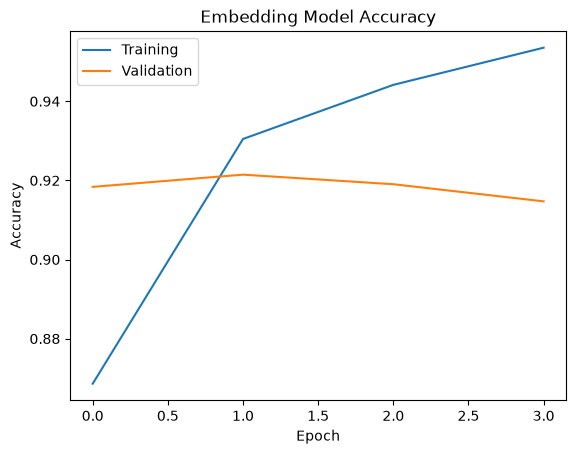

In [21]:
import matplotlib.pyplot as plt

plt.plot(history_embedding.history["accuracy"], label="Training")
plt.plot(history_embedding.history["val_accuracy"], label="Validation")

plt.title("Embedding Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

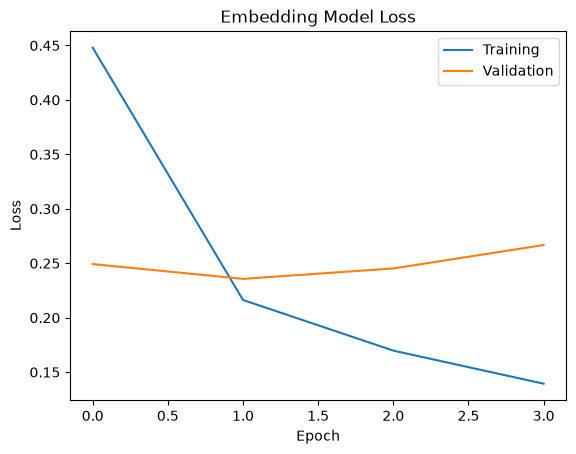

In [22]:
plt.plot(history_embedding.history["loss"], label="Training")
plt.plot(history_embedding.history["val_loss"], label="Validation")

plt.title("Embedding Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Embedding Model Evaluation

The embedding-based neural network achieved a validation accuracy of
**92.15%** and a validation loss of **0.2357**.

Training accuracy increased throughout the epochs, while validation
accuracy peaked around Epoch 2 and subsequently declined.

Validation loss also began increasing after Epoch 2, indicating
overfitting. EarlyStopping was used to restore the best weights.

### Model Comparison

| Model | Validation Accuracy |
|---|---:|
| TF-IDF + Logistic Regression | 91.90% |
| TF-IDF + Neural Network | 92.28% |
| Embedding + Neural Network | 92.15% |

The learned embedding model performed competitively with TF-IDF-based
approaches but did not outperform the TF-IDF neural network.

The next experiment will investigate pretrained contextual
representations using Transformer-based models.